In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 720  # 30 days of hourly data

timestamps = pd.date_range(start="2024-01-01", periods=n, freq="h")

# Normal usage — most hours look like this
cpu_usage = np.random.normal(loc=40, scale=5, size=n)       # ~40% CPU on average
cost = np.random.normal(loc=2.5, scale=0.3, size=n)         # ~$2.5/hr normally

# Inject anomalies — spikes at random hours
anomaly_indices = np.random.choice(n, size=15, replace=False)
cpu_usage[anomaly_indices] += np.random.uniform(40, 60, size=15)   # sudden CPU spike
cost[anomaly_indices] += np.random.uniform(5, 15, size=15)         # cost shoots up

df = pd.DataFrame({
    "timestamp": timestamps,
    "cpu_usage": cpu_usage,
    "cost_usd": cost
})

print(df.head())

              timestamp  cpu_usage  cost_usd
0   2024-01-01 00:00:00  42.483571  2.592341
1   2024-01-01 01:00:00  39.308678  1.986949
2   2024-01-01 02:00:00  43.238443  2.095544
3   2024-01-01 03:00:00  47.615149  2.722979
4   2024-01-01 04:00:00  38.829233  2.551260
..                  ...        ...       ...
715 2024-01-30 19:00:00  45.516509  2.584774
716 2024-01-30 20:00:00  40.571138  2.425393
717 2024-01-30 21:00:00  40.751509  2.982204
718 2024-01-30 22:00:00  38.181939  2.647292
719 2024-01-30 23:00:00  39.715272  2.720463

[720 rows x 3 columns]


In [13]:
from scipy import stats

df["z_score"] = np.abs(stats.zscore(df["cost_usd"]))
df["is_anomaly"] = df["z_score"] > 2.5 # threshold you can tune
df["z_score"].nlargest(5)

607    10.329293
263     9.981068
180     9.428265
494     7.125844
538     6.724664
Name: z_score, dtype: float64

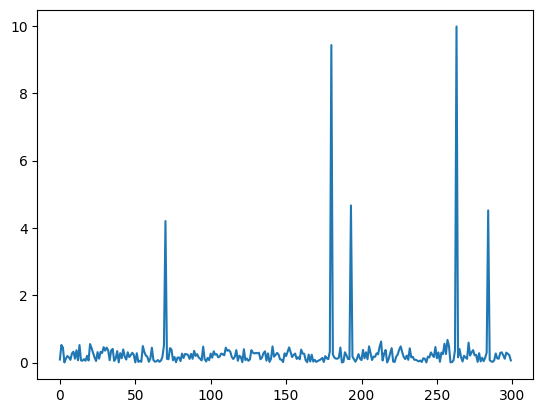

In [15]:
import matplotlib.pyplot as plt
plt.plot(df["z_score"].head(300))